In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from PROPS_EV.calculateEVS import *
from BACKTEST.backtest import *

## Load Model and Features

In [8]:
model = joblib.load('../MODELS/Models/xgbModel.pkl')
features = joblib.load('../MODELS/Models/top_features.pkl')

## Load Player Logs Data

In [3]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')

df = pd.concat([s25, s24]).sort_values(by='GAME_DATE')

## Load Odds for Single Bookies

In [5]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/singleBookies.csv')
backtestData = backtestData[(backtestData['ODDS'] <= 200) & (backtestData['ODDS'] >= -200)]
backtestData = backtestData[backtestData['CATEGORY'] == 'points']
backtestData.head()

,NAME,CATEGORY,SIDE,BOOKMAKER,LINE,ODDS,fair_line,fair_odds,GAME_DATE
7,Jesse Edwards,points,over,espnbet,28.5,110,28.5,129,2024-10-23
9,LeBron James,points,under,espnbet,15.5,-140,15.5,-117,2024-10-23
10,LeBron James,points,over,espnbet,15.5,100,15.5,117,2024-10-23
13,Jesse Edwards,points,under,espnbet,28.5,-160,28.5,-129,2024-10-23
14,Jaime Jaquez,points,under,fanduel,15.5,-125,11.5,100,2024-10-23


## Single game backtest for single bets

In [6]:
results = backtestSingle(df, backtestData, '2024-12-31',model, features, edge_threshold=4.5, top_n=10, simulations=10000)

# Calculate metrics
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['won'].sum()
    win_rate = results['won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['won'].sum()
        rec_win_rate = recommended['won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4.5) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")
results

Processing single bets...

--- All Bets ---
Total: 10, Wins: 7, Win Rate: 70.00%

--- Recommended Bets (Edge > 4.5) ---
Total: 10, Wins: 7, Win Rate: 70.00%


,player,bookmaker,side,line,odds,pred,actual,edge,recommendation,won,date
0,Shai Gilgeous-Alexander,draftkings,under,39.5,110,27.166349,35,-12.333651,1,1,2024-12-31
1,Jakob Poeltl,draftkings,over,7.5,110,12.721219,13,5.221219,1,1,2024-12-31
2,Shai Gilgeous-Alexander,espnbet,under,39.5,-110,27.166349,35,-12.333651,1,1,2024-12-31
3,Payton Pritchard,draftkings,under,19.5,-115,12.672256,21,-6.827744,1,0,2024-12-31
4,Jaylen Brown,draftkings,over,12.5,-140,25.897387,31,13.397387,1,1,2024-12-31
5,Jalen Williams,draftkings,over,13.5,-125,19.618988,14,6.118988,1,1,2024-12-31
6,De'Aaron Fox,espnbet,under,31.5,-160,19.044865,33,-12.455135,1,0,2024-12-31
7,Jayson Tatum,draftkings,over,23.5,-125,29.225016,22,5.725016,1,0,2024-12-31
8,Austin Reaves,fanduel,under,34.5,-174,26.491100,26,-8.008900,1,1,2024-12-31
9,Donovan Mitchell,fanduel,under,29.5,-152,22.809099,23,-6.690901,1,1,2024-12-31


## Grabs all dates in playerlogs to backtest full year

In [12]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestSingle(df, backtestData, date, model, features, edge_threshold=4.5, top_n=10, simulations=10000)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-10-24... 2/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-10-25... 3/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-10-26... 4/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-10-27... 5/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-10-28... 6/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-10-29... 7/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-10-30... 8/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-10-31... 9/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-11-01... 10/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-11-02... 11/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-11-03... 12/162
Processing single bets...
  ✓ Processed 10 bets
Processing 2024-11-04... 13/162
Processing single

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,598
   Wins: 1,226
   Hit Rate: 76.72%
   Total Profit: $4,831.74
   Total Staked: $7,990.00
   ROI: 60.47%
   Volatility: $22.45
   Max Drawdown: $-30.83
   Sharpe Ratio: 17.011

 RECOMMENDED BETS ANALYSIS (Edge > 4.5):
   Total Bets: 1,174
   Wins: 972
   Hit Rate: 82.79%
   Total Profit: $4,189.82
   Total Staked: $5,870.00
   ROI: 71.38%
   Volatility: $18.73
   Max Drawdown: $-21.43
   Sharpe Ratio: 17.737


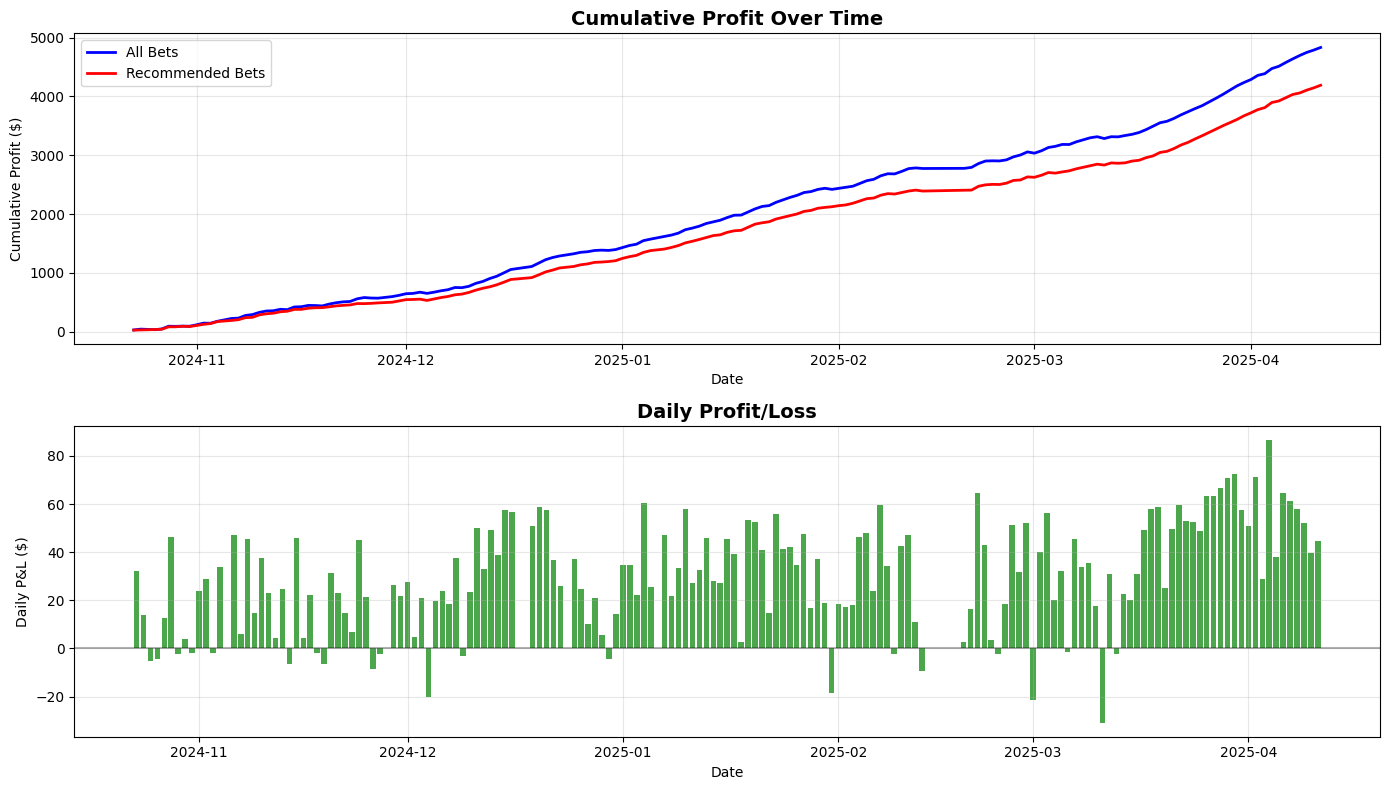

In [14]:

all_metrics = calculate_advanced_metrics(final_results, stake=5)
edge = 4.5 

# Calculate metrics for recommended bets only
recommended = final_results[final_results['recommendation'] == 1]
rec_metrics = calculate_advanced_metrics(recommended)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='blue')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='red')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()